# Watershed Flood Response Chain

This notebook implements a full watershed analysis chain: DEM QA, terrain derivatives, D8 flow routing, stream extraction, outlet basin tracing, susceptibility scoring, and runoff scenario comparison.

In [1]:
from pathlib import Path
import os, warnings
os.environ.setdefault("PROJ_LIB", "/opt/conda/share/proj")
os.environ.setdefault("PROJ_DATA", "/opt/conda/share/proj")
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from scipy import ndimage
from IPython.display import display, Markdown
PROJECT = Path.cwd()
DATA = PROJECT / "data"
OUTPUTS = PROJECT / "outputs"
OUTPUTS.mkdir(exist_ok=True)
print("Data files:", [p.name for p in sorted(DATA.iterdir())])

Data files: ['dem.tif', 'design_storm.csv', 'outlets.csv']


In [2]:
with rasterio.open(DATA / "dem.tif") as src:
    dem = src.read(1)
    profile = src.profile
rain = pd.read_csv(DATA / "design_storm.csv")
outlets = pd.read_csv(DATA / "outlets.csv")
print(f"DEM shape={dem.shape}, elevation range={dem.min():.1f}-{dem.max():.1f} m")
display(rain.head())
display(outlets)

DEM shape=(96, 96), elevation range=109.6-322.5 m


,hour,storm_mm
0,0,0.050638
1,1,0.146525
2,2,0.374165
3,3,0.843194
4,4,1.676898


,name,row,col
0,main_outlet,90,50
1,urban_outlet,82,64


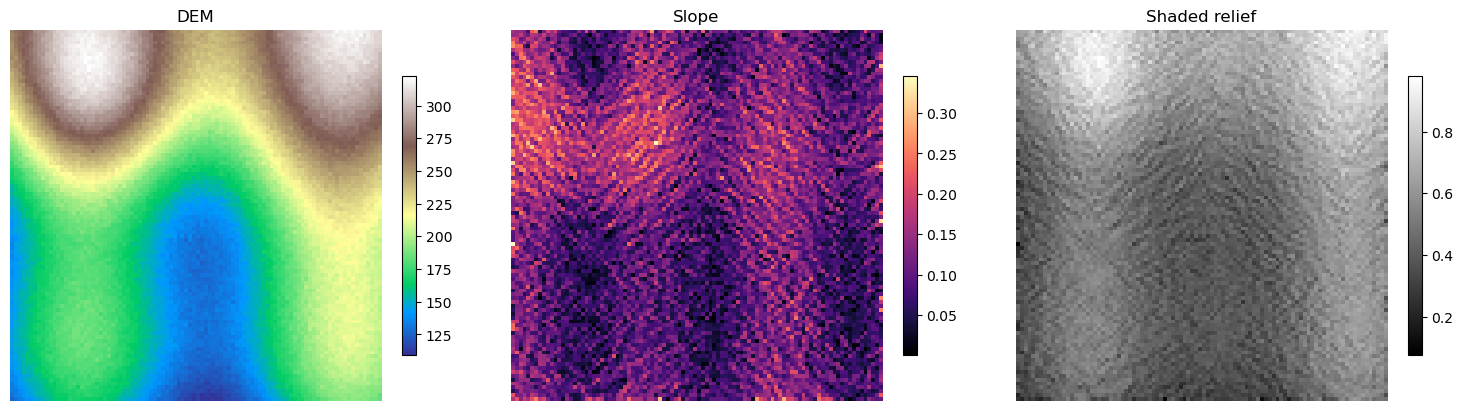

Saved outputs/terrain_derivatives.png


In [3]:
gy, gx = np.gradient(dem, 30, 30)
slope = np.hypot(gx, gy)
aspect = np.degrees(np.arctan2(-gx, gy))
hillshade = 0.6 * (dem - dem.min()) / (dem.max() - dem.min()) + 0.4 * (1 - slope / slope.max())
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, arr, title_, cmap in zip(axes, [dem, slope, hillshade], ["DEM", "Slope", "Shaded relief"], ["terrain", "magma", "gray"]):
    im = ax.imshow(arr, cmap=cmap)
    ax.set_title(title_)
    ax.axis("off")
    fig.colorbar(im, ax=ax, shrink=0.75)
fig.savefig(OUTPUTS / "terrain_derivatives.png", dpi=170)
plt.show()
print("Saved outputs/terrain_derivatives.png")

In [4]:
neighbors = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]
distances = np.array([np.sqrt(2), 1, np.sqrt(2), 1, 1, np.sqrt(2), 1, np.sqrt(2)])
flow_to = np.full(dem.shape + (2,), -1, dtype=int)
drop = np.zeros(dem.shape)
for r in range(1, dem.shape[0]-1):
    for c in range(1, dem.shape[1]-1):
        vals = np.array([(dem[r, c] - dem[r+dr, c+dc]) / d for (dr, dc), d in zip(neighbors, distances)])
        idx = int(np.argmax(vals))
        if vals[idx] > 0:
            dr, dc = neighbors[idx]
            flow_to[r, c] = [r + dr, c + dc]
            drop[r, c] = vals[idx]
print(f"Cells with downslope receiver: {np.sum(flow_to[...,0] >= 0)} / {dem.size}")
print(f"Median downslope gradient: {np.median(drop[drop>0]):.3f}")

Cells with downslope receiver: 8576 / 9216
Median downslope gradient: 3.904


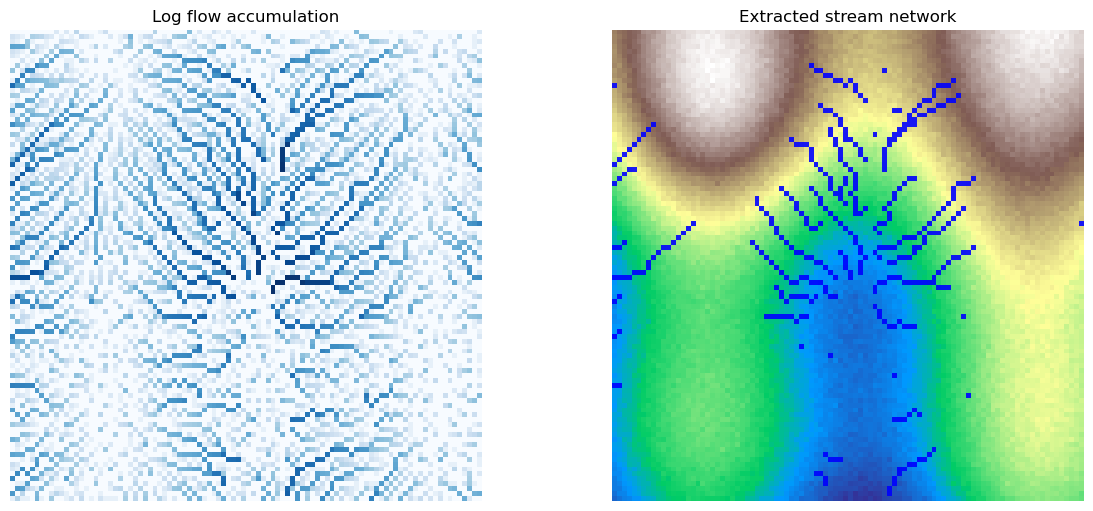

Stream cells: 368


In [5]:
order = np.argsort(dem.ravel())[::-1]
acc = np.ones(dem.shape, dtype=float)
for flat in order:
    r, c = np.unravel_index(flat, dem.shape)
    rr, cc = flow_to[r, c]
    if rr >= 0:
        acc[rr, cc] += acc[r, c]
streams = acc > np.percentile(acc, 96)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
axes[0].imshow(np.log1p(acc), cmap="Blues")
axes[0].set_title("Log flow accumulation")
axes[1].imshow(dem, cmap="terrain")
axes[1].imshow(np.where(streams, 1, np.nan), cmap="winter", alpha=0.9)
axes[1].set_title("Extracted stream network")
for ax in axes:
    ax.axis("off")
fig.savefig(OUTPUTS / "flow_accumulation_streams.png", dpi=170)
plt.show()
print(f"Stream cells: {int(streams.sum())}")

Outlet main_outlet basin cells=20, area=0.02 sq km


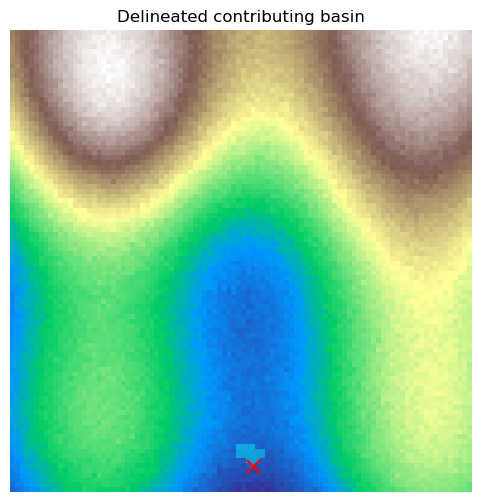

In [6]:
outlet = outlets.iloc[0]
target = (int(outlet.row), int(outlet.col))
reverse = {}
for r in range(dem.shape[0]):
    for c in range(dem.shape[1]):
        rr, cc = flow_to[r, c]
        if rr >= 0:
            reverse.setdefault((rr, cc), []).append((r, c))
stack = [target]
basin = np.zeros(dem.shape, dtype=bool)
while stack:
    cell = stack.pop()
    if basin[cell]:
        continue
    basin[cell] = True
    stack.extend(reverse.get(cell, []))
print(f"Outlet {outlet['name']} basin cells={basin.sum()}, area={basin.sum() * 30 * 30 / 1e6:.2f} sq km")
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(dem, cmap="terrain")
ax.imshow(np.where(basin, 1, np.nan), cmap="cool", alpha=0.42)
ax.scatter([target[1]], [target[0]], c="red", marker="x", s=90)
ax.set_title("Delineated contributing basin")
ax.axis("off")
fig.savefig(OUTPUTS / "delineated_basin.png", dpi=170)
plt.show()

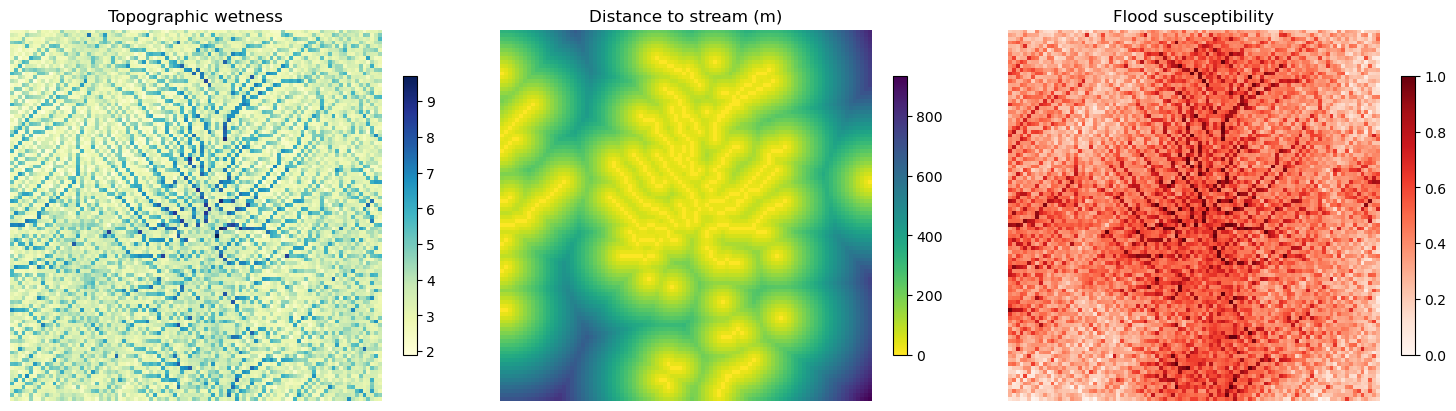

High susceptibility cells in basin: 2


In [7]:
stream_distance = ndimage.distance_transform_edt(~streams) * 30
twi = np.log1p(acc) - np.log(np.maximum(slope, 0.002))
twi_norm = (twi - np.nanpercentile(twi, 2)) / (np.nanpercentile(twi, 98) - np.nanpercentile(twi, 2))
dist_norm = 1 - np.clip(stream_distance / np.percentile(stream_distance, 90), 0, 1)
slope_norm = 1 - np.clip(slope / np.percentile(slope, 95), 0, 1)
susceptibility = np.clip(0.45 * twi_norm + 0.35 * dist_norm + 0.20 * slope_norm, 0, 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, arr, title_, cmap in zip(axes, [twi, stream_distance, susceptibility], ["Topographic wetness", "Distance to stream (m)", "Flood susceptibility"], ["YlGnBu", "viridis_r", "Reds"]):
    im = ax.imshow(arr, cmap=cmap)
    ax.set_title(title_)
    ax.axis("off")
    fig.colorbar(im, ax=ax, shrink=0.75)
fig.savefig(OUTPUTS / "flood_susceptibility_chain.png", dpi=170)
plt.show()
print(f"High susceptibility cells in basin: {int(((susceptibility > 0.72) & basin).sum())}")

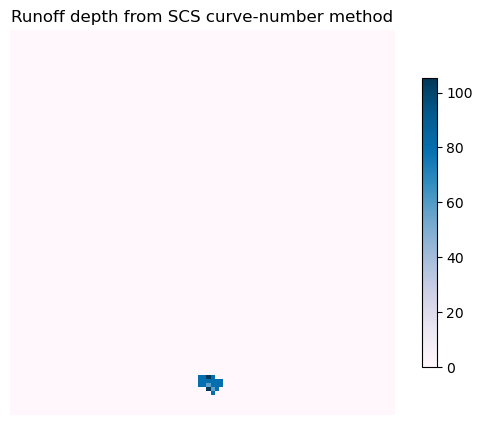

Design storm total=139.6 mm; estimated basin runoff=1,440 cubic meters


In [8]:
curve_number = np.where(susceptibility > 0.72, 88, np.where(susceptibility > 0.45, 78, 68))
curve_number = np.where(basin, curve_number, np.nan)
storm_total = rain["storm_mm"].sum()
S = 25400 / curve_number - 254
runoff_depth = np.where(storm_total > 0.2 * S, ((storm_total - 0.2 * S) ** 2) / (storm_total + 0.8 * S), 0)
runoff_volume = np.nansum(runoff_depth * 30 * 30 / 1000)
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(runoff_depth, cmap="PuBu")
ax.set_title("Runoff depth from SCS curve-number method")
ax.axis("off")
fig.colorbar(im, ax=ax, shrink=0.75)
fig.savefig(OUTPUTS / "runoff_depth_map.png", dpi=170)
plt.show()
print(f"Design storm total={storm_total:.1f} mm; estimated basin runoff={runoff_volume:,.0f} cubic meters")

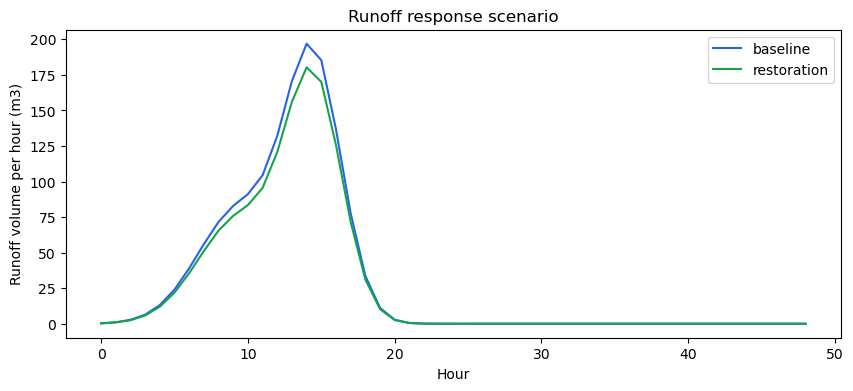

,hour,baseline_m3,restoration_m3
0,0,0.3,0.2
1,1,1.0,0.9
2,2,2.7,2.5
3,3,6.4,5.8
4,4,13.1,12.0
5,5,24.0,21.9
6,6,39.0,35.6
7,7,56.0,51.2
8,8,71.6,65.5
9,9,82.9,75.9


In [9]:
def route_hydrograph(depth_map, restoration=False):
    depth = depth_map.copy()
    if restoration:
        restored = (susceptibility > 0.62) & basin
        depth = np.where(restored, depth * 0.78, depth)
    delay = np.clip((stream_distance / 120).astype(int), 0, 24)
    response = np.zeros(49)
    for h, rain_mm in zip(rain["hour"], rain["storm_mm"]):
        contribution = depth / max(storm_total, 1) * rain_mm
        for lag in range(25):
            response[int(h) + lag] += np.nansum(contribution[delay == lag] * 30 * 30 / 1000)
    return response

base_h = route_hydrograph(runoff_depth, restoration=False)
rest_h = route_hydrograph(runoff_depth, restoration=True)
hydro = pd.DataFrame({"hour": np.arange(len(base_h)), "baseline_m3": base_h, "restoration_m3": rest_h})
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hydro["hour"], hydro["baseline_m3"], label="baseline", color="#2563eb")
ax.plot(hydro["hour"], hydro["restoration_m3"], label="restoration", color="#16a34a")
ax.set_title("Runoff response scenario")
ax.set_xlabel("Hour")
ax.set_ylabel("Runoff volume per hour (m3)")
ax.legend()
fig.savefig(OUTPUTS / "runoff_response_scenario.png", dpi=170)
plt.show()
display(hydro.head(12).round(1))

In [10]:
risk_table = pd.DataFrame({
    "metric": ["basin_area_sq_km", "storm_total_mm", "baseline_peak_m3", "restoration_peak_m3", "peak_reduction_pct", "high_susceptibility_cells"],
    "value": [
        basin.sum() * 30 * 30 / 1e6,
        storm_total,
        base_h.max(),
        rest_h.max(),
        100 * (1 - rest_h.max() / base_h.max()),
        int(((susceptibility > 0.72) & basin).sum()),
    ],
})
display(risk_table.round(2))
risk_table.to_csv(OUTPUTS / "watershed_risk_summary.csv", index=False)
hydro.to_csv(OUTPUTS / "runoff_hydrograph.csv", index=False)

,metric,value
0,basin_area_sq_km,0.02
1,storm_total_mm,139.65
2,baseline_peak_m3,196.89
3,restoration_peak_m3,180.30
4,peak_reduction_pct,8.42
5,high_susceptibility_cells,2.00


In [11]:
with rasterio.open(OUTPUTS / "flood_susceptibility.tif", "w", **profile) as dst:
    dst.write(susceptibility.astype("float32"), 1)
with rasterio.open(OUTPUTS / "flow_accumulation.tif", "w", **profile) as dst:
    dst.write(acc.astype("float32"), 1)
print("Exported files:")
for path in sorted(OUTPUTS.iterdir()):
    print(f"- {path.name} ({path.stat().st_size} bytes)")

Exported files:
- delineated_basin.png (42481 bytes)
- flood_susceptibility.tif (37260 bytes)
- flood_susceptibility_chain.png (155712 bytes)
- flow_accumulation.tif (37260 bytes)
- flow_accumulation_streams.png (82647 bytes)
- runoff_depth_map.png (21912 bytes)
- runoff_hydrograph.csv (1335 bytes)
- runoff_response_scenario.png (64813 bytes)
- terrain_derivatives.png (145611 bytes)
- watershed_risk_summary.csv (210 bytes)


In [12]:
display(Markdown(f'''## Case conclusion

The delineated basin covers **{basin.sum() * 30 * 30 / 1e6:.2f} sq km**. The restoration scenario reduces the modeled peak runoff by **{100 * (1 - rest_h.max() / base_h.max()):.1f}%**, and the exported susceptibility map identifies stream-adjacent cells with high wetness and slow drainage.
'''))

## Case conclusion

The delineated basin covers **0.02 sq km**. The restoration scenario reduces the modeled peak runoff by **8.4%**, and the exported susceptibility map identifies stream-adjacent cells with high wetness and slow drainage.
